# Aprendizaje por minimización del error con el dataset Iris

**Análisis y procesamiento de Señales** - Bioingeniería - Fac. de Ingeniería - UNSTA - 2026

En la clase pasada implementamos un perceptrón con la **Regla del Perceptrón** y vimos que tiene una limitación importante: cuando los datos **no son linealmente separables**, el algoritmo **nunca converge**.

En esta notebook vamos a:

1. Adaptar el perceptrón de clase 5 a la **Regla Delta** (descenso por gradiente sobre el SSE).
2. Verificar que **resuelve** el caso no separable que dejó atascada a la regla anterior.
3. Implementar la versión con **mini-batches** y compararla con SGD.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

## 1. El problema de la clase pasada

En la clase 5 entrenamos un perceptrón con la **Regla del Perceptrón**:

$$\Delta w_i = \eta \cdot (d - y) \cdot x_i$$

donde $y$ era la salida del **escalón**. Vimos que:

- Con *setosa* vs *versicolor* (linealmente separables) → **converge** en pocas épocas.
- Con *versicolor* vs *virginica* (no separables) → **nunca converge**, oscila siempre con varias muestras mal clasificadas.

Vamos a trabajar con el caso difícil para ver cómo lo resuelve la Regla Delta.

In [2]:
iris = sns.load_dataset("iris")

mask = iris["species"].isin(["versicolor", "virginica"])
data = iris[mask].reset_index(drop=True)
X = data[["petal_length", "petal_width"]].values
d = (data["species"] == "virginica").astype(int).values

print(f"Cantidad de muestras: {len(X)}")
print(f"Clases: 0 = versicolor, 1 = virginica")

Cantidad de muestras: 100
Clases: 0 = versicolor, 1 = virginica


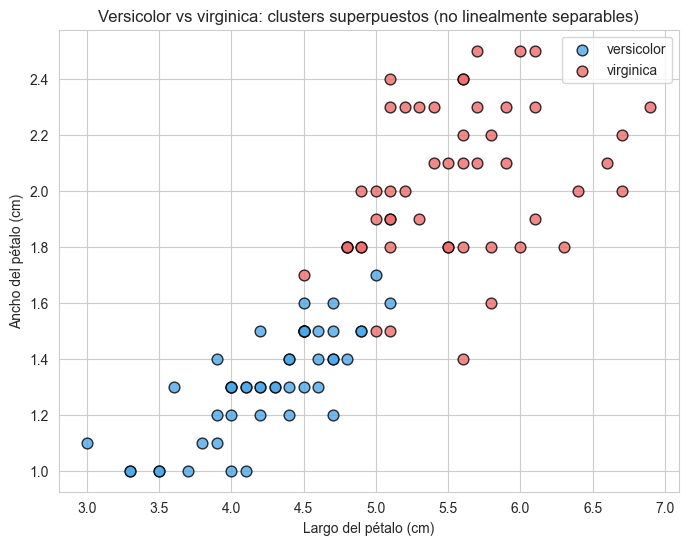

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
for cls, color, name in zip([0, 1], ["#4da6e8", "#ef6c6c"], ["versicolor", "virginica"]):
    mask = d == cls
    ax.scatter(X[mask, 0], X[mask, 1], color=color, s=60, edgecolor="black", alpha=0.8, label=name)
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_ylabel("Ancho del pétalo (cm)")
ax.set_title("Versicolor vs virginica: clusters superpuestos (no linealmente separables)")
ax.legend()
plt.show()

Se ve claramente que **no existe ninguna recta** que separe perfectamente los dos clusters: hay puntos azules y rojos mezclados en la zona de transición. Cualquier separador lineal va a clasificar mal algunas muestras.

## 2. De la Regla del Perceptrón a la Regla Delta

La idea de la **Regla Delta** (slides 47–53 de clase 5b/6) es cambiar el objetivo del entrenamiento: en vez de exigir error **exactamente cero**, vamos a **minimizar una función de costo continua**.

Como función de costo usamos el **SSE** (*Sum of Squared Errors*):

$$E_{SSE}(\vec{W}) = \frac{1}{2} \sum_{j=1}^{p} \left(d_j - y_j\right)^{2}$$

Para poder hacer descenso por gradiente, necesitamos dos cambios respecto a la clase pasada:

**Cambio 1 — activación derivable:** la función escalón **no es derivable**, así que la cambiamos por la **sigmoide**:

$$y = \sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma'(z) = y(1 - y)$$

**Cambio 2 — actualización por gradiente:** aplicando la regla de la cadena (slide 51), la derivada parcial del costo respecto a un peso $w_i$ es:

$$\frac{\partial E_{SSE}}{\partial w_i} = -\sum_{j=1}^{p} (d_j - y_j) \cdot \sigma'(z_j) \cdot x_i^{(j)}$$

Y el descenso por gradiente nos da:

$$w_i(t+1) = w_i(t) - \eta \cdot \frac{\partial E_{SSE}}{\partial w_i}$$

En la versión **estocástica** (una muestra a la vez), para sigmoide queda:

$$\boxed{\Delta w_i = \eta \cdot (d - y) \cdot y(1-y) \cdot x_i}$$

Comparado lado a lado:

| | Regla del Perceptrón | Regla Delta (con sigmoide) |
|---|---|---|
| Activación | Escalón | Sigmoide |
| Update | $\Delta w_i = \eta(d-y)\,x_i$ | $\Delta w_i = \eta(d-y)\,y(1-y)\,x_i$ |
| ¿Optimiza algo explícito? | No | Sí, $E_{SSE}$ |
| Criterio de paro | Error = 0 | Umbral de costo o n° de épocas |
| ¿En datos no separables? | **No converge** | **Converge** al mínimo del SSE |

## 3. Implementación

Lo único que cambia respecto a la clase 5 es la activación y la fórmula del update. Todo lo demás (inicialización, truco del bias, mezcla de muestras) queda igual.

In [4]:
class PerceptronDelta:
    def __init__(self, n_inputs, eta=0.1, max_epochs=500, seed=42):
        rng = np.random.default_rng(seed)
        self.W = rng.uniform(-1, 1, size=n_inputs + 1)
        self.eta = eta
        self.max_epochs = max_epochs
        self.history = {"sse": [], "errors": [], "weights": [self.W.copy()]}

    def _add_bias(self, X):
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-z))

    def predict_proba(self, X):
        Xb = self._add_bias(X)
        return self._sigmoid(Xb @ self.W)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def fit(self, X, d):
        Xb = self._add_bias(X)
        n_samples = len(X)
        rng = np.random.default_rng(0)

        for epoch in range(self.max_epochs):
            for i in rng.permutation(n_samples):
                x_i, d_i = Xb[i], d[i]
                z = x_i @ self.W
                y = self._sigmoid(z)
                # Δw = η · (d - y) · y(1 - y) · x   (Regla Delta con sigmoide)
                self.W += self.eta * (d_i - y) * y * (1 - y) * x_i

            # Métricas al final de cada época
            y_all = self.predict_proba(X)
            sse = 0.5 * np.sum((d - y_all) ** 2)
            errors = ((y_all >= 0.5).astype(int) != d).sum()
            self.history["sse"].append(sse)
            self.history["errors"].append(errors)
            self.history["weights"].append(self.W.copy())

## 4. Entrenamiento sobre el caso no separable

Entrenamos sobre *versicolor vs virginica* (el caso que NO convergía con la Regla del Perceptrón):

In [5]:
perceptron = PerceptronDelta(n_inputs=2, eta=0.1, max_epochs=500)
perceptron.fit(X, d)

print(f"SSE final: {perceptron.history['sse'][-1]:.3f}")
print(f"Errores de clasificación finales: {perceptron.history['errors'][-1]} / {len(X)}")
print(f"Precisión: {(1 - perceptron.history['errors'][-1] / len(X)) * 100:.1f}%")

SSE final: 2.294
Errores de clasificación finales: 7 / 100
Precisión: 93.0%


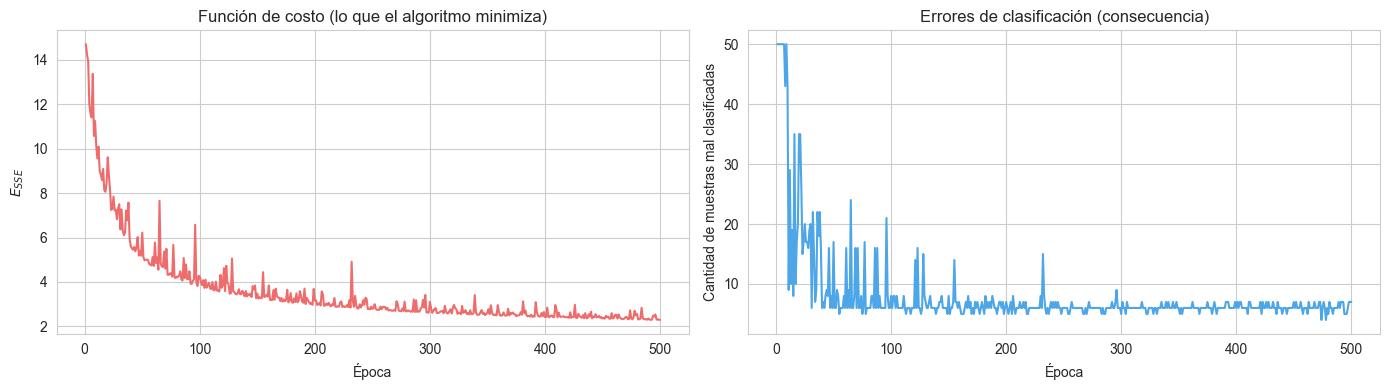

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, len(perceptron.history["sse"]) + 1), perceptron.history["sse"], color="#ef6c6c")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("$E_{SSE}$")
axes[0].set_title("Función de costo (lo que el algoritmo minimiza)")

axes[1].plot(range(1, len(perceptron.history["errors"]) + 1), perceptron.history["errors"], color="#4da6e8")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Cantidad de muestras mal clasificadas")
axes[1].set_title("Errores de clasificación (consecuencia)")

plt.tight_layout()
plt.show()

Tres observaciones clave:

- El **SSE baja monótonamente** y se estabiliza en un valor mínimo. Esto es exactamente lo que prometía la teoría: el descenso por gradiente garantiza bajar el costo.
- La **cantidad de errores** también baja y se estabiliza, pero en un valor **distinto de cero** — no podía ser de otra forma, porque los datos no son perfectamente separables.
- A diferencia de la Regla del Perceptrón, **el algoritmo no oscila violentamente**: se queda quieto en el mínimo del SSE.

## 5. Frontera de decisión

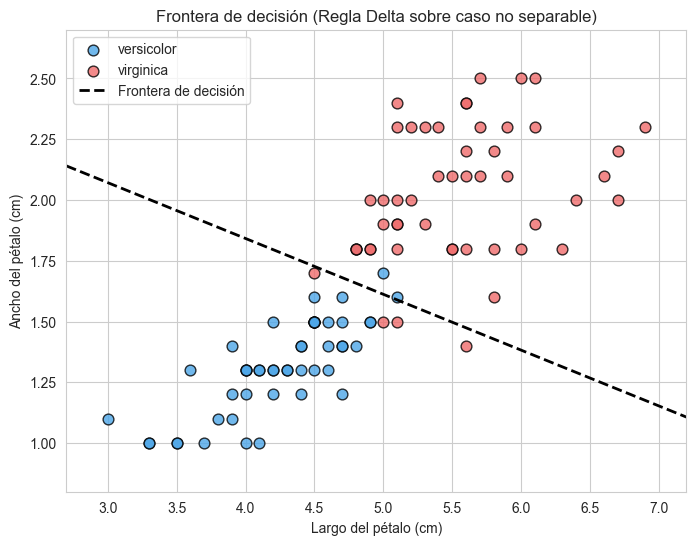

In [7]:
def plot_boundary(perceptron, X, d, ax, class_names):
    for cls, color in zip([0, 1], ["#4da6e8", "#ef6c6c"]):
        mask = d == cls
        ax.scatter(X[mask, 0], X[mask, 1], label=class_names[cls],
                   color=color, s=60, edgecolor="black", alpha=0.8)

    w1, w2, b = perceptron.W
    x1_min, x1_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    x1_range = np.array([x1_min, x1_max])
    if abs(w2) > 1e-9:
        x2_line = -(w1 * x1_range + b) / w2
        ax.plot(x1_range, x2_line, "k--", linewidth=2, label="Frontera de decisión")

    ax.set_xlabel("Largo del pétalo (cm)")
    ax.set_ylabel("Ancho del pétalo (cm)")
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(X[:, 1].min() - 0.2, X[:, 1].max() + 0.2)
    ax.legend(loc="upper left")


fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(perceptron, X, d, ax, {0: "versicolor", 1: "virginica"})
ax.set_title("Frontera de decisión (Regla Delta sobre caso no separable)")
plt.show()

La frontera quedó bien posicionada **entre los dos clusters**, dejando del lado correcto a la mayoría de los puntos. Las pocas muestras mal clasificadas son las que están en la zona de superposición — no hay ninguna recta que pueda clasificarlas correctamente.

> Esta es la diferencia fundamental con la Regla del Perceptrón: en vez de **exigir** una solución perfecta (que no existe), la Regla Delta **encuentra el mejor compromiso posible** dado el modelo lineal.

## 6. Animación del entrenamiento

Veamos en movimiento cómo el descenso por gradiente va **moviendo la frontera de decisión** y **bajando el costo** a lo largo de las épocas. Para que la animación dure unos pocos segundos tomamos snapshots cada cierta cantidad de épocas (no las 500).

In [8]:
from matplotlib import animation, rc

rc("animation", html="html5")

# Sub-muestreamos los snapshots de pesos para mantener la animación corta
stride = max(1, len(perceptron.history["weights"]) // 180)
frame_indices = list(range(0, len(perceptron.history["weights"]), stride))
n_frames = len(frame_indices)

# Elementos fijos pre-calculados
total_epochs = len(perceptron.history["sse"])
sse_max = max(perceptron.history["sse"]) * 1.1
x1_min, x1_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
x2_min, x2_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

fig, (ax_loss, ax_bnd) = plt.subplots(1, 2, figsize=(13, 5))


def update(i):
    epoch_idx = frame_indices[i]
    W = perceptron.history["weights"][epoch_idx]

    # Curva del SSE hasta esta época
    ax_loss.clear()
    if epoch_idx > 0:
        ax_loss.plot(range(1, epoch_idx + 1),
                     perceptron.history["sse"][:epoch_idx],
                     color="#ef6c6c", linewidth=2)
    ax_loss.set_xlim(0, total_epochs)
    ax_loss.set_ylim(0, sse_max)
    ax_loss.set_xlabel("Época")
    ax_loss.set_ylabel("$E_{SSE}$")
    ax_loss.set_title("Función de costo")
    ax_loss.grid(True, alpha=0.3)

    # Frontera de decisión en esta época
    ax_bnd.clear()
    for cls, color, name in zip([0, 1], ["#4da6e8", "#ef6c6c"], ["versicolor", "virginica"]):
        mask = d == cls
        ax_bnd.scatter(X[mask, 0], X[mask, 1], color=color, s=50,
                       edgecolor="black", alpha=0.7, label=name)
    w1, w2, b = W
    x1_range = np.array([x1_min, x1_max])
    if abs(w2) > 1e-9:
        x2_line = -(w1 * x1_range + b) / w2
        ax_bnd.plot(x1_range, x2_line, "k--", linewidth=2)
    ax_bnd.set_xlim(x1_min, x1_max)
    ax_bnd.set_ylim(x2_min, x2_max)
    ax_bnd.set_xlabel("Largo del pétalo (cm)")
    ax_bnd.set_ylabel("Ancho del pétalo (cm)")
    ax_bnd.set_title(f"Frontera de decisión — época {epoch_idx}")
    ax_bnd.legend(loc="upper left")
    ax_bnd.grid(True, alpha=0.3)

    plt.tight_layout()
    return ax_loss, ax_bnd


anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=200)
plt.close(fig)
anim

<Figure size 640x480 with 0 Axes>

Lo más interesante de la animación:

- El **SSE baja de forma suave y monótona** — es exactamente la curva que esperaríamos de un descenso por gradiente.
- La **frontera empieza mal posicionada** (en alguna esquina dependiendo de los pesos iniciales) y **migra suavemente** hasta el punto óptimo.
- En las **últimas épocas la frontera apenas se mueve**: el algoritmo "encontró" el mínimo y los gradientes son muy chicos.

Comparalo mentalmente con la animación de clase 5: ahí la frontera saltaba bruscamente entre updates porque la Regla del Perceptrón no estaba minimizando ninguna función continua. Acá, **la trayectoria es mucho más estable** porque el algoritmo está siguiendo el gradiente del SSE.

## 7. Comparación lado a lado con la Regla del Perceptrón

Para ver el contraste, entrenamos también un perceptrón con la regla de la clase pasada, sobre los mismos datos:

In [9]:
# La misma implementación de la clase 5, para comparar
class PerceptronRule:
    def __init__(self, n_inputs, eta=0.1, max_epochs=500, seed=42):
        rng = np.random.default_rng(seed)
        self.W = rng.uniform(-1, 1, size=n_inputs + 1)
        self.eta = eta
        self.max_epochs = max_epochs
        self.history = {"errors": [], "weights": [self.W.copy()]}

    def _add_bias(self, X):
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def predict(self, X):
        Xb = self._add_bias(X)
        return (Xb @ self.W >= 0).astype(int)

    def fit(self, X, d):
        Xb = self._add_bias(X)
        rng = np.random.default_rng(0)
        for epoch in range(self.max_epochs):
            errors = 0
            for i in rng.permutation(len(X)):
                x_i, d_i = Xb[i], d[i]
                y = 1 if x_i @ self.W >= 0 else 0
                if y != d_i:
                    self.W += self.eta * (d_i - y) * x_i
                    errors += 1
            self.history["errors"].append(errors)
            self.history["weights"].append(self.W.copy())
            if errors == 0:
                return


p_rule = PerceptronRule(n_inputs=2, eta=0.1, max_epochs=500)
p_rule.fit(X, d)

print(f"Regla del Perceptrón -> errores finales: {p_rule.history['errors'][-1]} / {len(X)}")
print(f"Regla Delta          -> errores finales: {perceptron.history['errors'][-1]} / {len(X)}")

Regla del Perceptrón -> errores finales: 11 / 100
Regla Delta          -> errores finales: 7 / 100


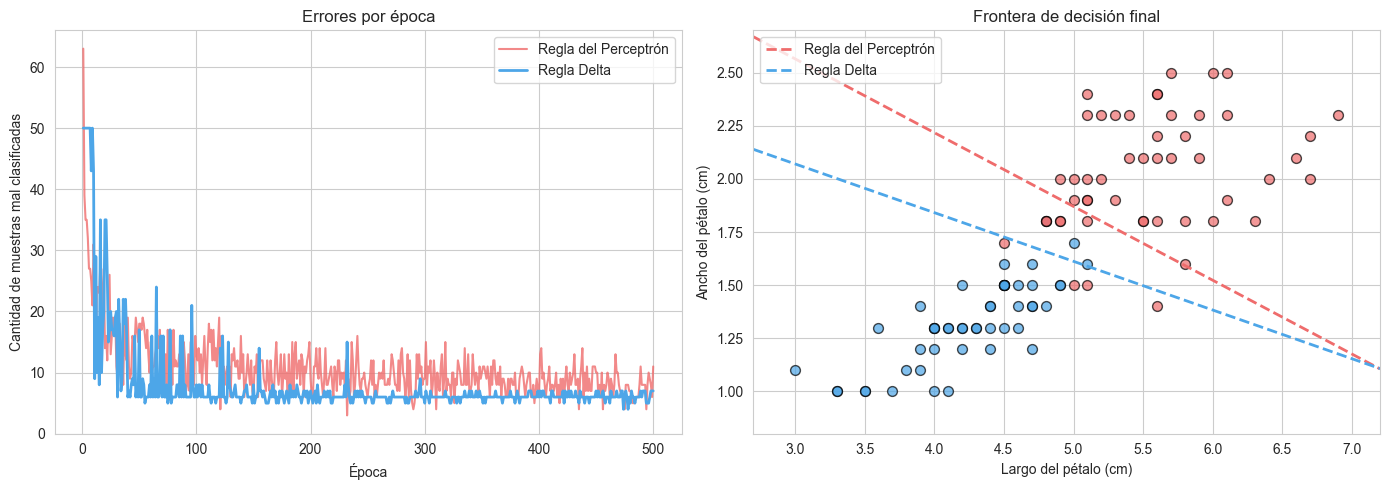

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(p_rule.history["errors"]) + 1), p_rule.history["errors"],
             color="#ef6c6c", label="Regla del Perceptrón", alpha=0.8)
axes[0].plot(range(1, len(perceptron.history["errors"]) + 1), perceptron.history["errors"],
             color="#4da6e8", label="Regla Delta", linewidth=2)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Cantidad de muestras mal clasificadas")
axes[0].set_title("Errores por época")
axes[0].legend()

# Fronteras de decisión finales
for cls, color in zip([0, 1], ["#4da6e8", "#ef6c6c"]):
    mask = d == cls
    axes[1].scatter(X[mask, 0], X[mask, 1], color=color, s=50, edgecolor="black", alpha=0.7)

x1_min, x1_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
x1_range = np.array([x1_min, x1_max])

w1r, w2r, br = p_rule.W
if abs(w2r) > 1e-9:
    axes[1].plot(x1_range, -(w1r * x1_range + br) / w2r, "--", color="#ef6c6c",
                 linewidth=2, label="Regla del Perceptrón")

w1d, w2d, bd = perceptron.W
if abs(w2d) > 1e-9:
    axes[1].plot(x1_range, -(w1d * x1_range + bd) / w2d, "--", color="#4da6e8",
                 linewidth=2, label="Regla Delta")

axes[1].set_xlim(x1_min, x1_max)
axes[1].set_ylim(X[:, 1].min() - 0.2, X[:, 1].max() + 0.2)
axes[1].set_xlabel("Largo del pétalo (cm)")
axes[1].set_ylabel("Ancho del pétalo (cm)")
axes[1].set_title("Frontera de decisión final")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

La diferencia es contundente:

- La **Regla del Perceptrón** (rojo) **oscila salvajemente** durante todas las épocas. Su frontera final depende del último update y suele estar mal ubicada.
- La **Regla Delta** (azul) **converge a un mínimo estable** del SSE. Su frontera queda razonablemente bien posicionada entre los dos clusters.

Y todo esto con **el mismo set de datos**, **la misma tasa de aprendizaje** y **la misma inicialización** — la única diferencia está en la regla de actualización y la activación.

## 8. Mini-batches

Hasta ahora actualizamos los pesos **muestra por muestra** (SGD, *Stochastic Gradient Descent*). Cada update solo "ve" una muestra y la dirección puede ser ruidosa.

La idea del **mini-batch** (slide 14): acumular el gradiente sobre un subconjunto de muestras (ej. 16 o 32) y actualizar los pesos **una sola vez por batch**. Promediar 16 muestras da una estimación del gradiente **mucho menos ruidosa** que una sola.

Vamos a implementarlo y ver el efecto. Para que la comparación sea limpia, **usamos exactamente el mismo learning rate** ($\eta = 0.1$) en ambos casos.

In [11]:
class PerceptronDeltaBatch:
    def __init__(self, n_inputs, eta=0.1, batch_size=16, max_epochs=500, seed=42):
        rng = np.random.default_rng(seed)
        self.W = rng.uniform(-1, 1, size=n_inputs + 1)
        self.eta = eta
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.history = {"sse": [], "errors": [], "weights": [self.W.copy()]}

    def _add_bias(self, X):
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-z))

    def predict_proba(self, X):
        return self._sigmoid(self._add_bias(X) @ self.W)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def fit(self, X, d):
        Xb = self._add_bias(X)
        n_samples = len(X)
        rng = np.random.default_rng(0)

        for epoch in range(self.max_epochs):
            indices = rng.permutation(n_samples)
            for start in range(0, n_samples, self.batch_size):
                batch = indices[start:start + self.batch_size]
                x_batch = Xb[batch]
                d_batch = d[batch]
                z = x_batch @ self.W
                y = self._sigmoid(z)
                # Gradiente promediado sobre el batch
                grad = -((d_batch - y) * y * (1 - y))[:, None] * x_batch
                self.W -= self.eta * grad.mean(axis=0)

            y_all = self.predict_proba(X)
            sse = 0.5 * np.sum((d - y_all) ** 2)
            errors = ((y_all >= 0.5).astype(int) != d).sum()
            self.history["sse"].append(sse)
            self.history["errors"].append(errors)
            self.history["weights"].append(self.W.copy())


p_batch = PerceptronDeltaBatch(n_inputs=2, eta=0.1, batch_size=16, max_epochs=500)
p_batch.fit(X, d)

print(f"SGD                   -> SSE final: {perceptron.history['sse'][-1]:.3f}, errores: {perceptron.history['errors'][-1]}")
print(f"Mini-batch (batch=16) -> SSE final: {p_batch.history['sse'][-1]:.3f}, errores: {p_batch.history['errors'][-1]}")
print()
print(f"Updates por época  -> SGD: {len(X)},  Mini-batch: {(len(X) + 15) // 16}")

SGD                   -> SSE final: 2.294, errores: 7
Mini-batch (batch=16) -> SSE final: 5.908, errores: 6

Updates por época  -> SGD: 100,  Mini-batch: 7


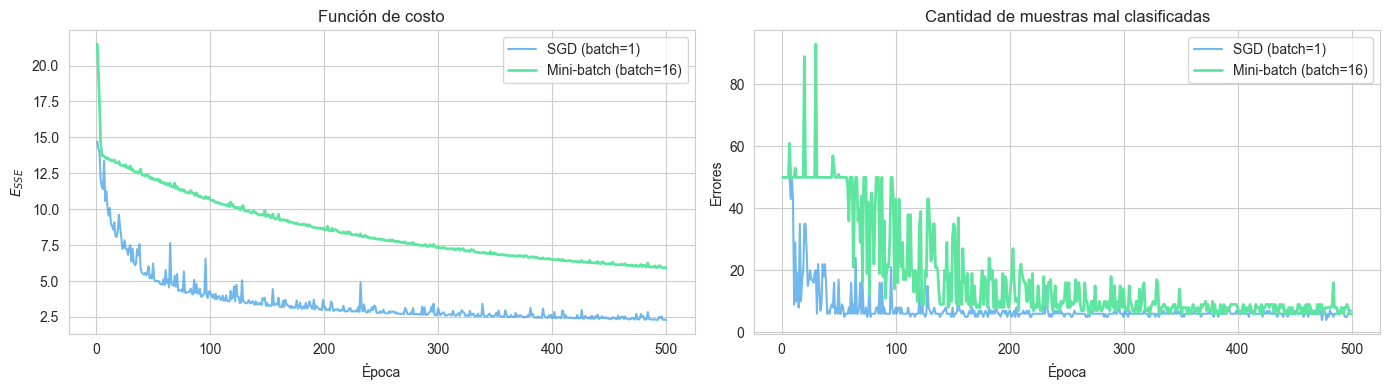

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, len(perceptron.history["sse"]) + 1), perceptron.history["sse"],
             color="#4da6e8", label="SGD (batch=1)", alpha=0.8)
axes[0].plot(range(1, len(p_batch.history["sse"]) + 1), p_batch.history["sse"],
             color="#5ee6a0", label="Mini-batch (batch=16)", linewidth=2)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("$E_{SSE}$")
axes[0].set_title("Función de costo")
axes[0].legend()

axes[1].plot(range(1, len(perceptron.history["errors"]) + 1), perceptron.history["errors"],
             color="#4da6e8", label="SGD (batch=1)", alpha=0.8)
axes[1].plot(range(1, len(p_batch.history["errors"]) + 1), p_batch.history["errors"],
             color="#5ee6a0", label="Mini-batch (batch=16)", linewidth=2)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Errores")
axes[1].set_title("Cantidad de muestras mal clasificadas")
axes[1].legend()

plt.tight_layout()
plt.show()

Hay una **trade-off clara** entre los dos métodos:

- **SGD** (azul) **converge más rápido** (en menos épocas llega a SSE más bajo) porque hace **100 updates por época** — uno por cada muestra. Pero los updates son **ruidosos** (cada uno se basa en una sola muestra), así que la curva tiembla un poco.
- **Mini-batch** (verde) tiene una curva **mucho más suave** porque cada update promedia 16 muestras y tiene una dirección de descenso más confiable. Pero hace solo ~7 updates por época, así que **converge más lento** con la misma cantidad de épocas y el mismo $\eta$.

> **Nota práctica:** en problemas reales con datasets grandes, mini-batch (32, 64, 128, ...) es el estándar. Para compensar los menos updates por época, se suele **aumentar la tasa de aprendizaje** $\eta$ proporcionalmente al tamaño del batch. Pero hay que cuidar: si $\eta$ se hace muy grande, cada update es tan grande que vuelve a oscilar (lo opuesto de lo que buscábamos). Encontrar la combinación correcta de $\eta$ y batch size es **una de las decisiones de diseño más importantes** al entrenar redes.

## Conclusiones

- Adaptamos el perceptrón de la clase 5 cambiando dos cosas: **activación sigmoide** (derivable) y **update por gradiente del SSE**.
- La Regla Delta **resolvió** el caso no separable que dejaba atascada a la Regla del Perceptrón. La diferencia clave: el algoritmo busca **el mejor ajuste posible** en vez de exigir error cero.
- El **SSE baja monótonamente**, mientras que el **conteo de errores** (no derivable) puede tener saltos pero termina estabilizándose.
- **Mini-batches** producen una curva más **suave** que SGD a costa de **menos updates por época**.

> En la próxima notebook vamos a llevar este modelo a problemas con **más de dos clases** usando *Softmax* y *Entropía Cruzada Categórica*, y vamos a sumar **regularización L2** para combatir el sobreajuste.

## 6. Re-implementación con TensorFlow

Para cerrar, vamos a ver cómo se implementa este mismo clasificador (una única neurona con activación sigmoide) utilizando la librería **TensorFlow/Keras**. 

Noten que aunque aquí estamos haciendo algo muy simple, el flujo de trabajo (definir capas, compilar con un optimizador y una función de pérdida, y ajustar con `fit`) es el mismo que se utiliza para redes neuronales profundas.

In [13]:
import tensorflow as tf
import os
import logging

# Reducimos el ruido de logs de TF
tf.get_logger().setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"Versión de TensorFlow: {tf.__version__}")

Versión de TensorFlow: 2.21.0


In [14]:
# 1. Definimos la arquitectura: una sola capa densa con 1 neurona y activación sigmoide
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

# 2. Compilamos el modelo
# Usamos Descenso por Gradiente Estocástico (SGD) y Entropía Cruzada Binaria
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 3. Entrenamos el modelo
# replicamos el comportamiento de mini-batch con batch_size=16
history = model.fit(X, d, epochs=500, batch_size=16, verbose=0)

print("¡Entrenamiento completado!")
print(f"Loss final: {history.history['loss'][-1]:.4f}")
print(f"Accuracy final: {history.history['accuracy'][-1]*100:.1f}%")

/Users/facundolucianna/Docencia/UNSTA/Procesamiento/Repo/signal-processing-bioengineering-unsta/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


¡Entrenamiento completado!
Loss final: 0.2293
Accuracy final: 94.0%


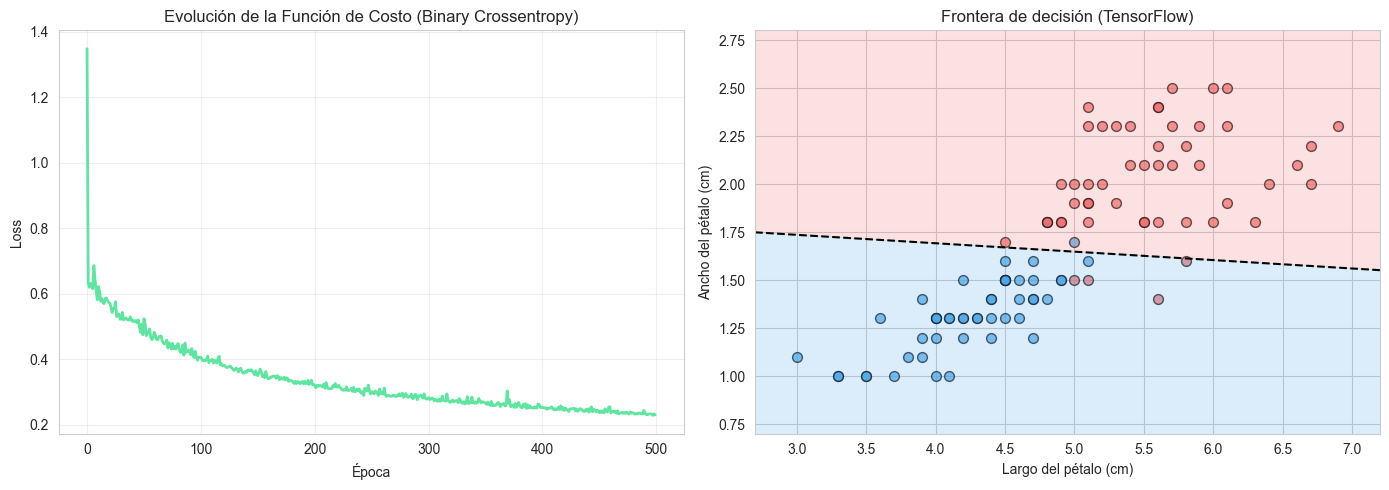

In [15]:
# Visualización de resultados
plt.figure(figsize=(14, 5))

# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color="#5ee6a0", linewidth=2)
plt.title("Evolución de la Función de Costo (Binary Crossentropy)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

# Frontera de decisión
plt.subplot(1, 2, 2)
for cls, color in zip([0, 1], ["#4da6e8", "#ef6c6c"]):
    mask = d == cls
    plt.scatter(X[mask, 0], X[mask, 1], color=color, s=50, edgecolor="black", alpha=0.7)

# Generamos malla para la frontera
x1_min, x1_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
x2_min, x2_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100), 
                         np.linspace(x2_min, x2_max, 100))
Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()], verbose=0)
Z = Z.reshape(xx1.shape)

plt.contourf(xx1, xx2, Z, levels=[0, 0.5, 1], alpha=0.2, colors=["#4da6e8", "#ef6c6c"])
plt.contour(xx1, xx2, Z, levels=[0.5], colors="black", linestyles="--")
plt.title("Frontera de decisión (TensorFlow)")
plt.xlabel("Largo del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")

plt.tight_layout()
plt.show()